In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.shape

(8807, 12)

In [8]:
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.to_csv("netflix_titles_cleaned.csv",index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


In [11]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

print("Missing values added")

Missing values added


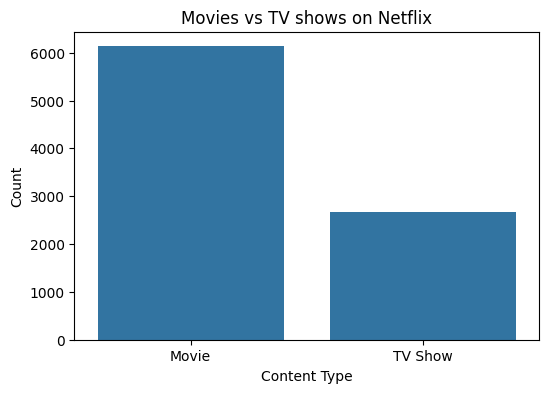

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [16]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [19]:
df["date_added"].sample(20)

726          June 13, 2021
7301         June 20, 2016
1324     February 11, 2021
6150       January 1, 2017
1389      January 21, 2021
2905     February 16, 2020
666          June 19, 2021
4883           May 3, 2018
7388     November 15, 2018
6046         July 22, 2018
4674       August 31, 2018
7090     September 1, 2017
3949         April 3, 2019
3347      November 1, 2019
1295     February 18, 2021
1233         March 5, 2021
7325     December 31, 2017
21      September 22, 2021
7667          May 15, 2018
1586      December 7, 2020
Name: date_added, dtype: str

In [20]:
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="%B %d, %Y"
)

df["year_added"] = df["date_added"].dt.year

print("Date conversion successful!")

Date conversion successful!


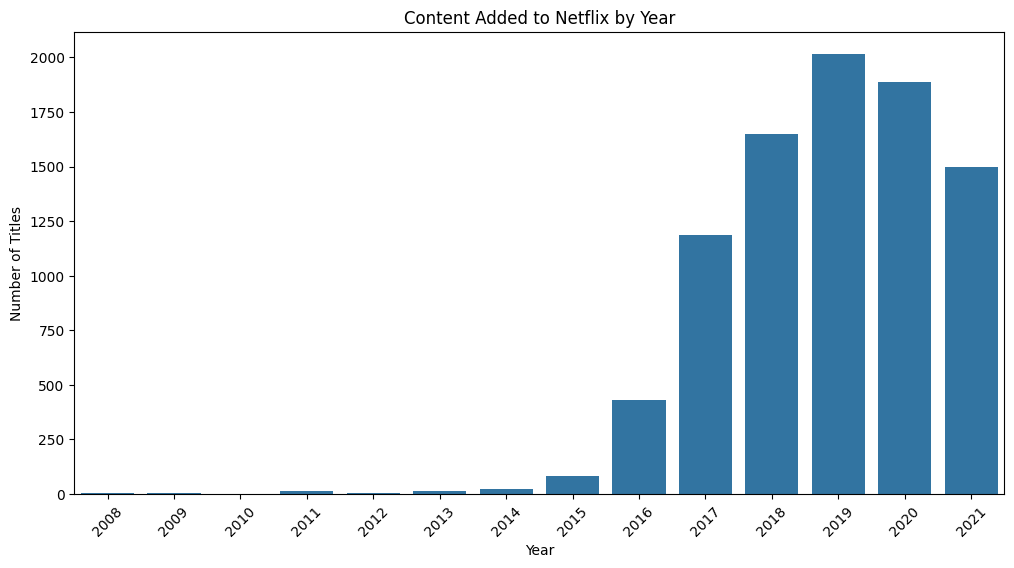

In [21]:
plt.figure(figsize=(12,6))

sns.countplot(
  data = df,
  x = "year_added",
  order = sorted(df["year_added"].unique())
)

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [22]:
df["year_added"].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
Name: count, dtype: int64

In [25]:
top_countries = df["country"].value_counts().head(10)
top_countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

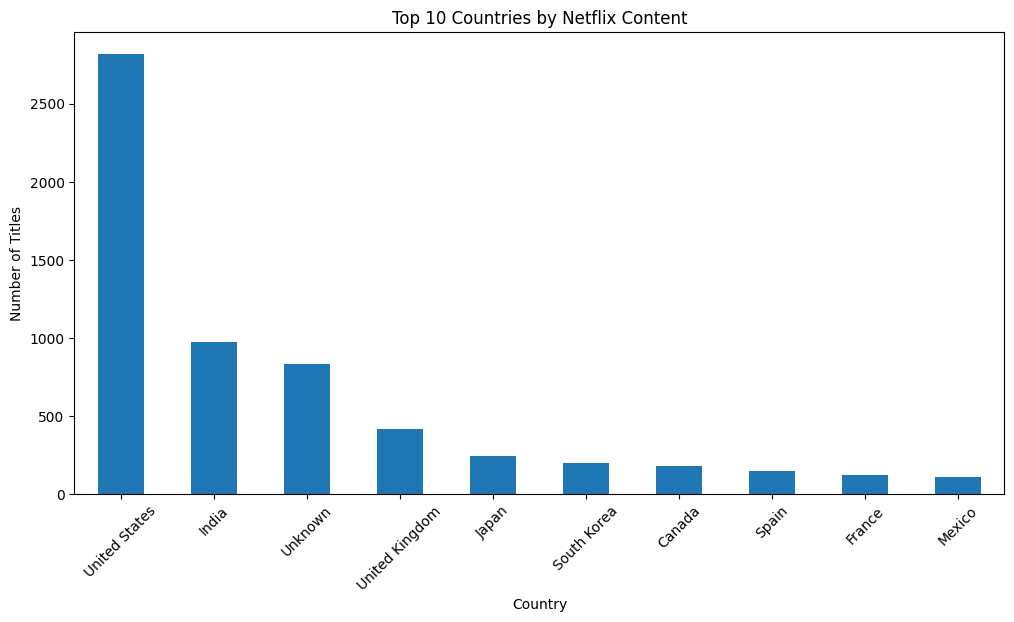

In [26]:
plt.figure(figsize = (12,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [38]:
df = pd.read_csv("netflix_titles.csv")
df["listed_in"].head()

df_genre = df.copy()
df_genre = df_genre.dropna(subset=["listed_in"])
df_genre["listed_in"] = df_genre["listed_in"].str.split(",")

In [39]:
df["listed_in"] = df["listed_in"].str.split(",")

df_exploded = df.explode("listed_in")

df_exploded["listed_in"] = df_exploded["listed_in"].str.strip()

top_genres = df_exploded["listed_in"].value_counts().head(10)

top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

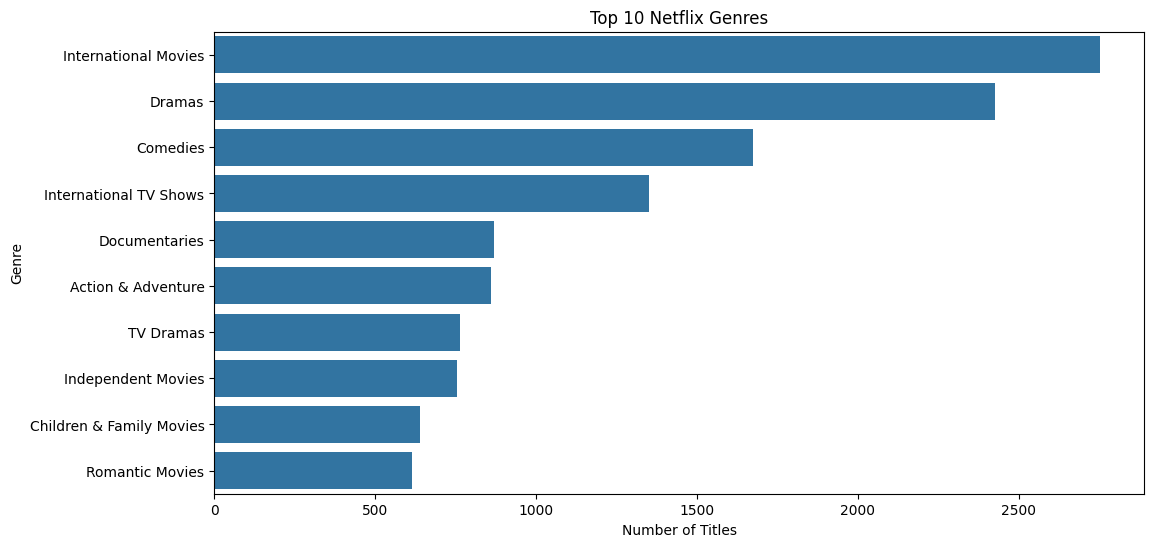

In [40]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values , y=top_genres.index)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()